# House Price Prediction Analysis

Complete notebook covering data exploration, cleaning, modeling, visualization, and insights.

In [26]:
# Importing libraries for data manipulation, visualization, machine learning, and model evaluation

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Setting the default style for visualizations
sns.set_style("whitegrid")

## Task 1 – Data Loading & Exploration

In [27]:
# Loading the housing dataset and perform initial data exploration

df = pd.read_csv('Housing.csv')

# Displaying the first 10 records of the dataset
print("First 10 Rows")
display(df.head(10))

# Displaying the number of rows and columns
print("\nShape:", df.shape)

# Displaying all column names in the dataset
print("\nColumns:")
print(df.columns.tolist())

# Checking for missing values in each column
print("\nMissing Values:")
print(df.isnull().sum())

First 10 Rows


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished



Shape: (545, 13)

Columns:
['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']

Missing Values:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [28]:
# Identifying the target variable and input features for model training
target_column = 'price'
feature_columns = [col for col in df.columns if col != target_column]

# Display the target column and feature columns
print("Target Column:", target_column)
print("Features:", feature_columns)

Target Column: price
Features: ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']


## Task 2 – Data Cleaning

In [29]:
# Cleaning the dataset by removing duplicates and handling missing values
df = df.drop_duplicates()

for col in df.columns:
    if df[col].dtype == 'object':
        # Fill missing values in categorical columns with the mode
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        # Fill missing values in numerical columns with the median
        df[col] = df[col].fillna(df[col].median())

# Converting categorical variables into numerical format using one-hot encoding
df_encoded = pd.get_dummies(df, drop_first=True)

# Displaying the shape and preview of the processed dataset
print(df_encoded.shape)
df_encoded.head()

(545, 14)


,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


## Task 3 – Model Building

In [30]:
# Preparing feature and target variables, then splitting the data into training and testing sets

X = df_encoded.drop('price', axis=1)
y = df_encoded['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [31]:
# Training a Linear Regression model and evaluating its performance on the test dataset

lr = LinearRegression()
lr.fit(X_train, y_train)

# Generating predictions using the trained model
lr_pred = lr.predict(X_test)

# Calculating evaluation metrics
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)

# Displaying model performance metrics
print("Linear Regression")
print("MAE:", lr_mae)
print("RMSE:", lr_rmse)
print("R2:", lr_r2)

Linear Regression
MAE: 970043.4039201637
RMSE: 1324506.9600914388
R2: 0.6529242642153184


In [32]:
# Training a Random Forest Regressor and evaluating its performance on the test dataset

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

# Generating predictions using the trained model
rf_pred = rf.predict(X_test)

# Calculating evaluation metrics
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

# Displaying model performance metrics
print("Random Forest Regressor")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R2:", rf_r2)

Random Forest Regressor
MAE: 1013968.579587156
RMSE: 1398115.6668385956
R2: 0.6132752494107068


In [33]:
# Creating a comparison table to evaluate the performance of both regression models

comparison = pd.DataFrame({
    'Model':['Linear Regression','Random Forest'],
    'MAE':[lr_mae, rf_mae],
    'RMSE':[lr_rmse, rf_rmse],
    'R2':[lr_r2, rf_r2]
})

comparison

,Model,MAE,RMSE,R2
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest,1.013969e+06,1.398116e+06,0.613275


## Task 4 – Visualizations

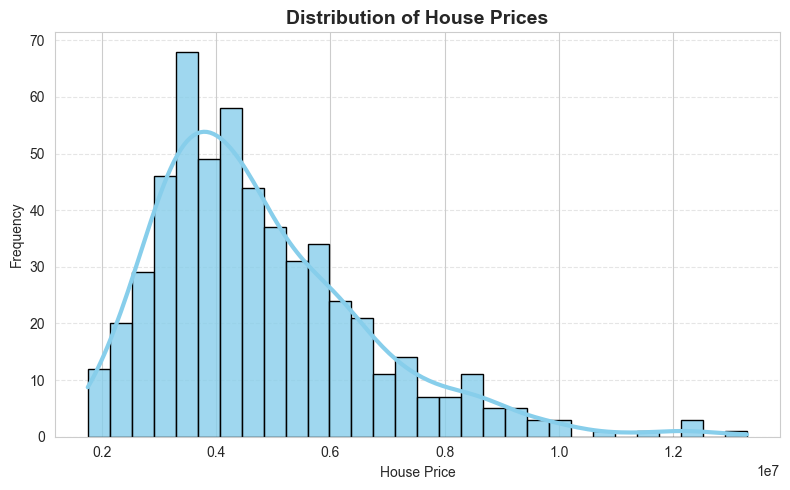

In [34]:
# Chart 1 - Distribution of House Prices

plt.figure(figsize=(8,5))

sns.histplot(
    df['price'],
    bins=30,
    kde=True,
    color='skyblue',
    edgecolor='black',
    alpha=0.8,
    line_kws={'linewidth': 3}
)

plt.title('Distribution of House Prices', fontsize=14, fontweight='bold')
plt.xlabel('House Price')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('charts/chart1_price_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

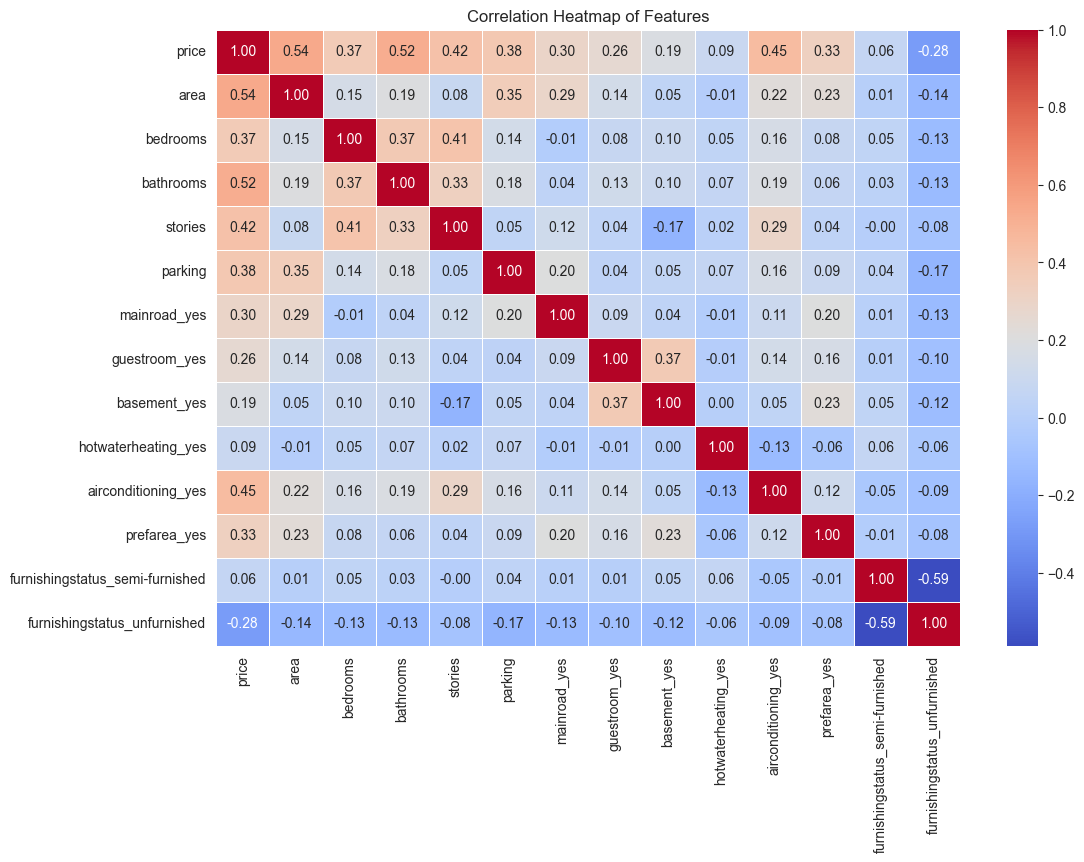

In [35]:
# Chart 2 - Correlation Heatmap of Features
plt.figure(figsize=(12,8))
corr = df_encoded.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Features')
plt.savefig('charts/chart2_correlation_heatmap.png')
plt.show()


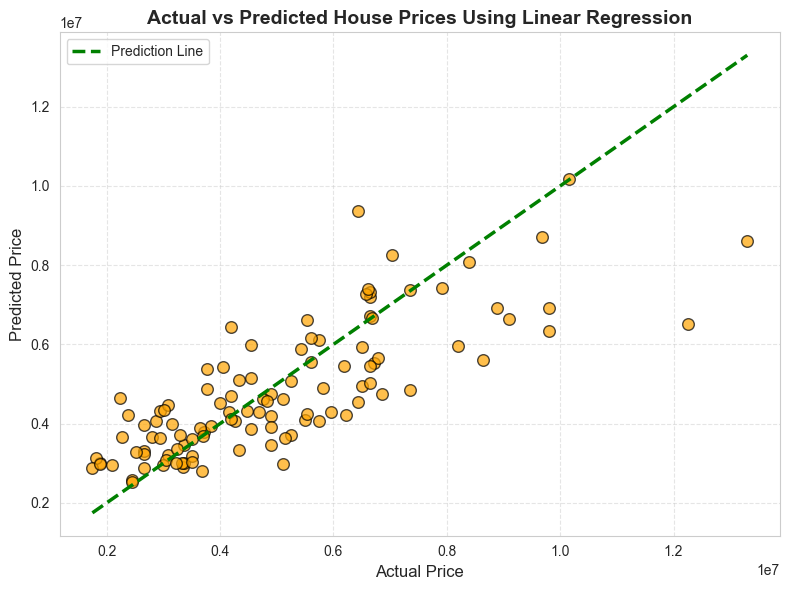

In [36]:
# Chart 3 - Actual vs Predicted House Prices (Random Forest)

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    rf_pred,
    color='orange',
    edgecolors='black',
    alpha=0.7,
    s=70
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='green',
    linestyle='--',
    linewidth=2.5,
    label='Prediction Line'
)

plt.title(
    'Actual vs Predicted House Prices Using Linear Regression',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Actual Price', fontsize=12)
plt.ylabel('Predicted Price', fontsize=12)

plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(
    'charts/chart3_actual_vs_predicted.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

In [37]:

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

importance.head(10)


,Feature,Importance
0,area,0.468535
2,bathrooms,0.152554
9,airconditioning_yes,0.060238
4,parking,0.057273
3,stories,0.057064
1,bedrooms,0.047370
12,furnishingstatus_unfurnished,0.036972
7,basement_yes,0.032176
10,prefarea_yes,0.028432
8,hotwaterheating_yes,0.018305


## Task 5 – Insights & Summary

- The most important factors affecting house prices are **area, bathrooms, air conditioning, parking, and number of stories**. Area was the strongest predictor, contributing nearly 47% of the total feature importance.

- The **Linear Regression model performed better** than the Random Forest model, achieving an **R² score of 65.29%**, meaning it explained about 65% of the variation in house prices.

- The distribution chart shows that most houses are concentrated in the mid-price range, while very expensive properties are relatively rare.

- A surprising observation was that amenities such as **air conditioning and parking** had a noticeable impact on house prices, whereas features like hot water heating had minimal influence.

- Real estate businesses can use predictive models to estimate property values more accurately and focus on properties with larger areas and desirable amenities to maximize returns.